## Proyecto 1: Los Simpsons


## Carga de librerías y dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV #para dividir los datos en entrenamiento y prueba, validación cruzada y búsqueda de hiperparámetros
from sklearn.preprocessing import OneHotEncoder #para las variables categóricas como director y escritor
from sklearn.preprocessing import StandardScaler #para escalar las variables numéricas
from sklearn.compose import ColumnTransformer #para aplicar diferentes transformaciones a diferentes columnas
from sklearn.pipeline import Pipeline #para encadenar las transformaciones y el modelo en un solo objeto
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet #regularización para evitar el overfitting
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error #metricas de evaluación del modelo

In [2]:
data = pd.read_csv('simpsons_episodes.csv')
data.head(10)


,id,title,description,original_air_date,production_code,directed_by,written_by,season,number_in_season,number_in_series,us_viewers_in_millions,imdb_rating,tmdb_rating,tmdb_vote_count
0,0,Simpsons Roasting on an Open Fire,Homer is forced to become a department store S...,1989-12-17,7G08,David Silverman,Mimi Pond,1,1,1,26.7,8.1,6.921,101
1,1,Bart the Genius,Bart ends up at a school for gifted children a...,1990-01-14,7G02,David Silverman,Jon Vitti,1,2,2,24.5,7.7,7.400,62
2,2,Homer's Odyssey,"After losing his job, Homer contemplates endin...",1990-01-21,7G03,Wes Archer,Jay Kogen & Wallace Wolodarsky,1,3,3,27.5,7.3,6.500,58
3,3,There's No Disgrace Like Home,After being embarrassed by the rest of the fam...,1990-01-28,7G04,Gregg Vanzo & Kent Butterworth,Al Jean & Mike Reiss,1,4,4,20.2,7.7,7.200,52
4,4,Bart the General,After being beaten up by Nelson Muntz one too ...,1990-02-04,7G05,David Silverman,John Swartzwelder,1,5,5,27.1,7.9,6.900,53
5,5,Moaning Lisa,A depressed Lisa's spirit is lifted when she m...,1990-02-11,7G06,Wes Archer,Al Jean & Mike Reiss,1,6,6,27.4,7.6,7.200,50
6,6,The Call of the Simpsons,"Homer takes the family camping, but it soon be...",1990-02-18,7G09,Wes Archer,John Swartzwelder,1,7,7,27.6,7.7,6.900,49
7,7,The Telltale Head,Bart gets more than he bargained for when he s...,1990-02-25,7G07,Rich Moore,"Al Jean, Mike Reiss, Sam Simon & Matt Groening",1,8,8,28.0,7.6,7.000,47
8,8,Life on the Fast Lane,Marge contemplates an affair with a handsome b...,1990-03-18,7G11,David Silverman,John Swartzwelder,1,9,9,33.5,7.4,6.800,47
9,9,Homer's Night Out,After a photograph of Homer canoodling with an...,1990-03-25,7G10,Rich Moore,Jon Vitti,1,10,10,30.3,7.3,6.700,45


## EDA

In [3]:
data.columns

Index(['id', 'title', 'description', 'original_air_date', 'production_code',
       'directed_by', 'written_by', 'season', 'number_in_season',
       'number_in_series', 'us_viewers_in_millions', 'imdb_rating',
       'tmdb_rating', 'tmdb_vote_count'],
      dtype='object')

In [4]:
data.shape


(747, 14)

El dataset de capítulos de Los Simpsons contiene 14 columnas las cuales son: id title description original_air_date production_code directed_by written_by season number_in_season number_in_series us_viewers_in_millions imdb_rating tmdb_rating tmdb_vote_count. Con 747 filas correspondiente a 747 episodios de distintas temporadas.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747 entries, 0 to 746
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      747 non-null    int64  
 1   title                   747 non-null    object 
 2   description             747 non-null    object 
 3   original_air_date       747 non-null    object 
 4   production_code         747 non-null    object 
 5   directed_by             747 non-null    object 
 6   written_by              747 non-null    object 
 7   season                  747 non-null    int64  
 8   number_in_season        747 non-null    int64  
 9   number_in_series        747 non-null    int64  
 10  us_viewers_in_millions  746 non-null    float64
 11  imdb_rating             747 non-null    float64
 12  tmdb_rating             747 non-null    float64
 13  tmdb_vote_count         747 non-null    int64  
dtypes: float64(3), int64(5), object(6)
memory 

Las colummnas numéricas son las que tienen Dtype "object": title, description, original_air_date, production_code,directed_by, written_by. Mientras que las numpericas enteras o decimales son las que tienen Dtype int64 y float64 respectivamente: id, season,number_in_season,number_in_series, us_viewers_in_millions, imdb_rating,tmdb_rating, tmdb_vote_count

### Valores nulos o duplicados

In [6]:
#Valores nulos o faltantes
data.isnull().sum()


id                        0
title                     0
description               0
original_air_date         0
production_code           0
directed_by               0
written_by                0
season                    0
number_in_season          0
number_in_series          0
us_viewers_in_millions    1
imdb_rating               0
tmdb_rating               0
tmdb_vote_count           0
dtype: int64

Solo falta un dato que es en la columna de los televidentes de Estados Unidos en millones

In [7]:
#Valores duplicados
data.duplicated().sum()

np.int64(0)

### Descripción del dataset

In [8]:
data.describe()

,id,season,number_in_season,number_in_series,us_viewers_in_millions,imdb_rating,tmdb_rating,tmdb_vote_count
count,747.000000,747.000000,747.000000,747.000000,746.000000,747.000000,747.000000,747.000000
mean,373.000000,17.444444,11.610442,374.325301,10.384531,7.150870,6.379029,18.070950
std,215.784615,9.734715,6.497023,216.271060,6.963214,0.818934,0.879565,8.874704
min,0.000000,1.000000,1.000000,1.000000,0.770000,4.000000,0.000000,1.000000
25%,186.500000,9.000000,6.000000,187.500000,4.755000,6.600000,5.800000,14.000000
50%,373.000000,17.000000,12.000000,374.000000,9.015000,7.000000,6.300000,17.000000
75%,559.500000,26.000000,17.000000,560.500000,14.837500,7.700000,7.000000,23.000000
max,746.000000,34.000000,25.000000,750.000000,33.600000,9.300000,8.600000,101.000000


- count: Muestra la cantidad de datos válidos que hay. La mayoría de las columnas dicen 747.000000 (747 episodios), pero us_viewers_in_millions dice 746.000000. Significa que hay 1 episodio al que le falta el dato de audiencia, tal como se vio en el estudio de datos nulos y su cantidad. 

- mean: se puede ver el promedio histórico de la serie. La serie promedia 17.4 temporadas, actualmente va en la temporada 37 con más de 800 episodios pero al momento de crear este dataset se consideraron solo 747. Además tiene una sintonía histórica promedio de 10.38 millones de espectadores por capítulo y la "nota" promedio en IMDb es de 7.15 dentro del rango de 1 al 10.

- std: la desviación estándar muestra que la audiencia es de 6.96, lo que significa que la sintonía ha cambiado drásticamente entre temporadas; alguinos capítulos con muchísima gente y otros con muy poca.

- min (Mínimo): es el punto más bajo registrado con el peor capítulo de Los Simpson teniendo un 4.0 en IMDb. Y el capítulo menos visto tuvo apenas 0.77 millones de espectadores.

- max (Máximo): la serie al momento de la creación de este dataset tiene un máximo de 34 temporadas, su capítulo más visto tuvo 33.6 millones de espectadores y el capítulo mejor evaluado de la historia llegó a 9.3 en IMDb.

- Respecto a los percentiles de 25%, 50% y 75%: el análisis del imdb_rating muestra que la calidad de la serie se concentra en rangos bien marcados. El 25% de los episodios tiene una nota de 6.60 o menos, lo que representa las etapas con menor desempeño. Por otro lado, la amediana es la mitad del show y se ubica exactamente en 7.00; al ser una nota más baja que el promedio general de 7.15, se demuestra que un grupo selecto de capítulos clásicos y muy exitosos empuja la media hacia arriba. Finalmente, el 75% de la serie alcanza como máximo un 7.70, lo que significa que solo un exclusivo 25% de los episodios logra superar esa barrera. 


### Variables categóricas

Se despliega la cantidad de episodios dirigidos y escrito por cada persona

In [9]:
data["directed_by"].value_counts().head(10)

directed_by
Mark Kirkland         83
Steven Dean Moore     82
Bob Anderson          64
Matthew Nastuk        57
Mike Frank Polcino    39
Jim Reardon           35
Chris Clements        32
Rob Oliver            32
Nancy Kruse           26
Wes Archer            25
Name: count, dtype: int64

In [10]:
data["written_by"].value_counts().head(10)

written_by
John Swartzwelder    55
Joel H. Cohen        32
Tim Long             27
J. Stewart Burns     25
Michael Price        25
John Frink           24
Matt Selman          24
Jeff Westbrook       22
Jon Vitti            22
Carolyn Omine        19
Name: count, dtype: int64

- Directores: Mark Kirkland y Steven Dean Moore son los que han dirigido más episodios en toda la serie (con 83 y 82 respectivamente), seguidos de lejos por Bob Anderson con 64.

- Guionistas: John Swartzwelder es el que más capítulos ha escrito con harta diferencia (55 en total), mientras que el resto de los escritores ronda entre los 20 y 32 episodios.

### Análisis de variables y su relación: gráficas

### Boxplot para variables de calificación y audiencia

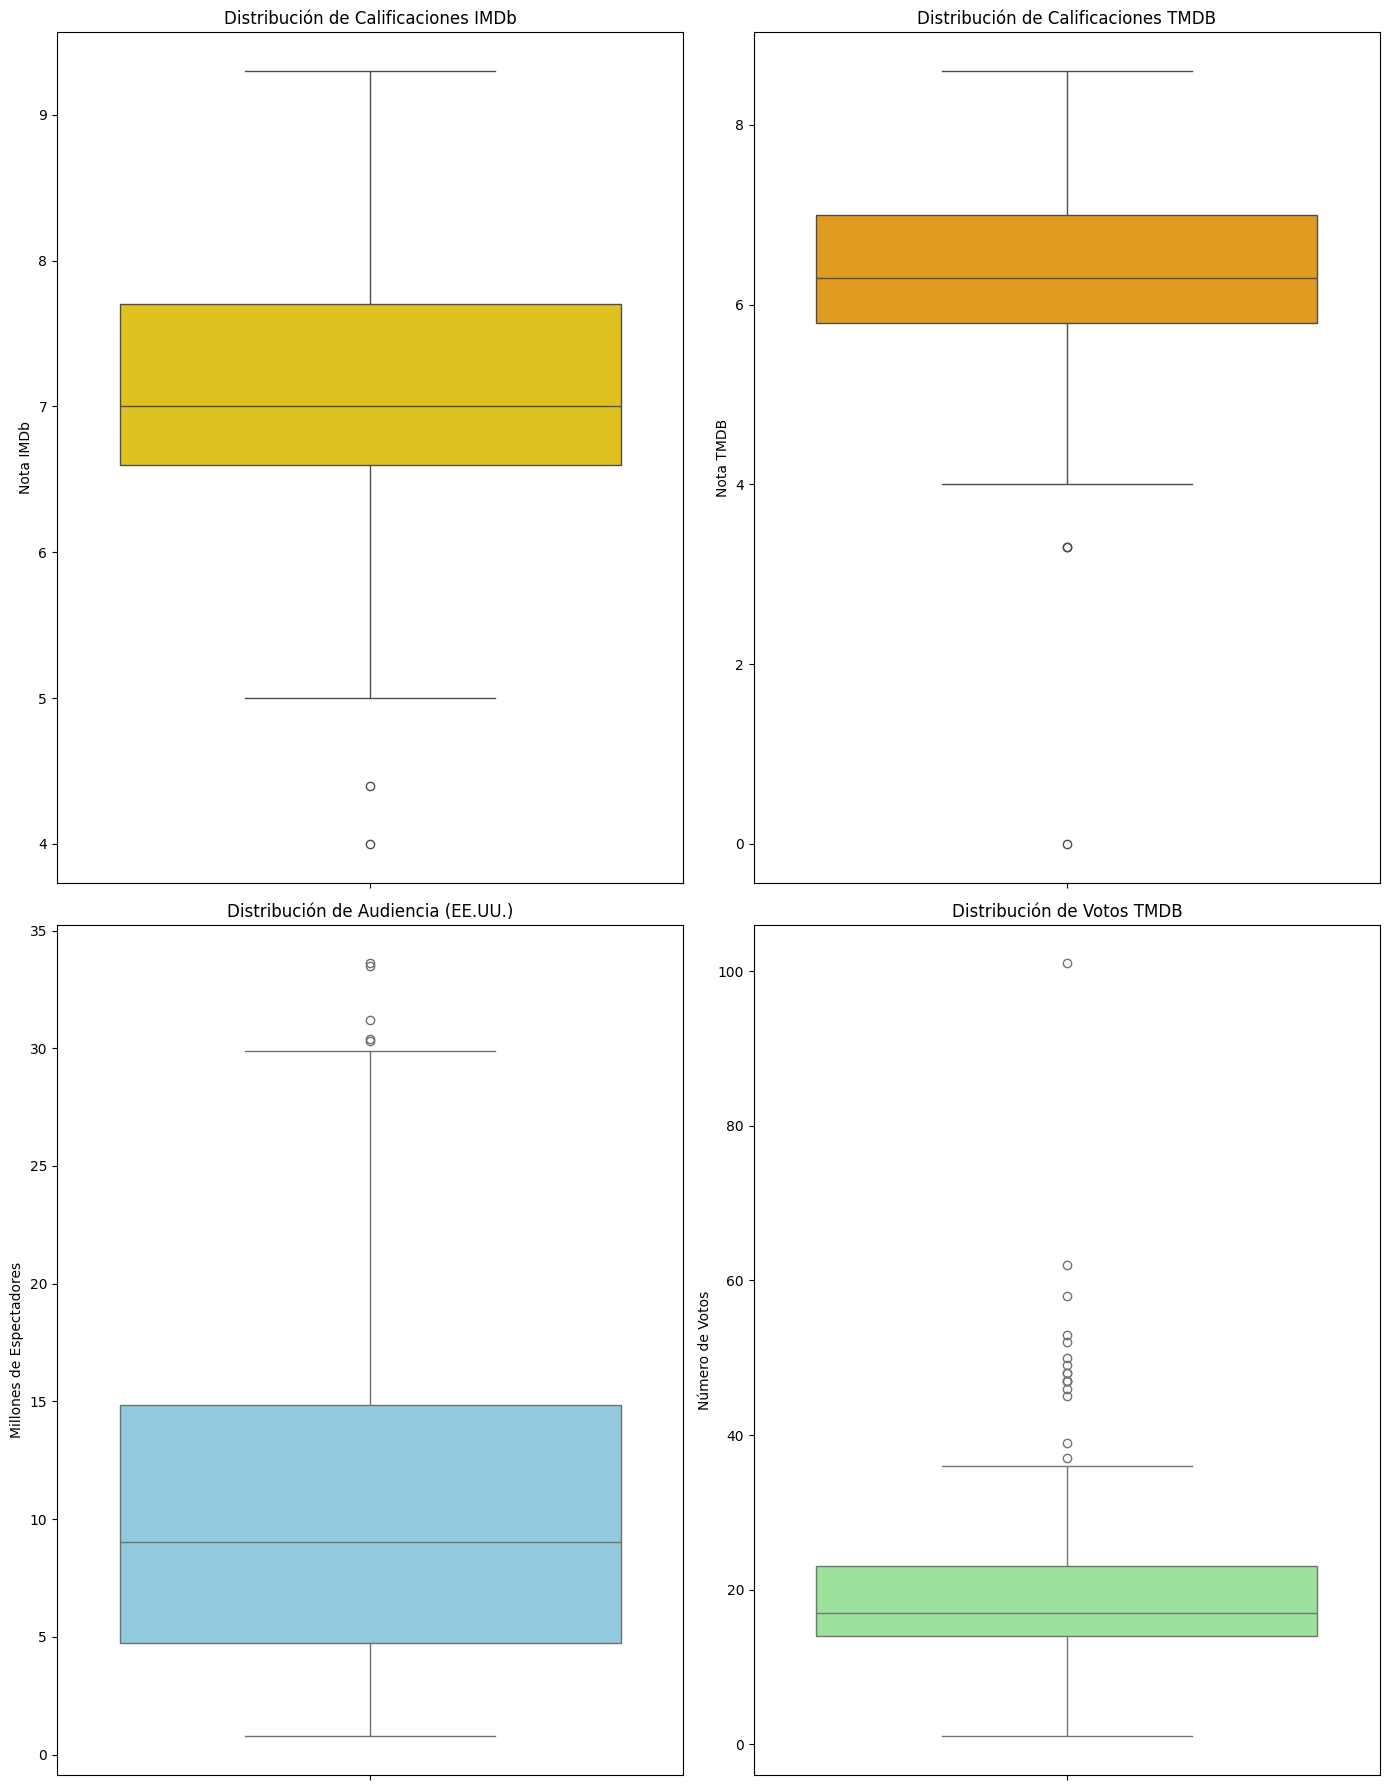

In [11]:
# Se crea una grilla de 2 filas y 2 columnas para los boxplots, así se pueden comparar fácilmente las distribuciones de cada variable y no ir una por una
fig, axes = plt.subplots(2, 2, figsize=(14, 18))

# 1. Calificaciones IMDb (1 al 10)
sns.boxplot(data=data, y='imdb_rating', ax=axes[0, 0], color='gold')
axes[0, 0].set_title('Distribución de Calificaciones IMDb')
axes[0, 0].set_ylabel('Nota IMDb')

# 2. Calificaciones TMDB (1 al 10)
sns.boxplot(data=data, y='tmdb_rating', ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Distribución de Calificaciones TMDB')
axes[0, 1].set_ylabel('Nota TMDB')

# 3. Audiencia (Millones)
sns.boxplot(data=data, y='us_viewers_in_millions', ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Distribución de Audiencia (EE.UU.)')
axes[1, 0].set_ylabel('Millones de Espectadores')

# 4. Votos TMDB (Número de votos)
sns.boxplot(data=data, y='tmdb_vote_count', ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Distribución de Votos TMDB')
axes[1, 1].set_ylabel('Número de Votos')


# Ajustar espacios para que no se vea encima el texto
plt.tight_layout()
plt.savefig('boxplots_completos_simpsons.png')
plt.show()

Distribución de Calificaciones IMDb
- Mediana: 7.0
- Media (promedio general): 7.15 
- Primer Cuartil (25%): 6.6 
- Tercer Cuartil (75%): 7.7 
- max: 9.3 
- mín: 5.0 
- Valores atípicos: Un capítulo en 4.4 y otro en 4

Distribución de Calificaciones TMDB
- Mediana: 6.3
- Media: 6.37
- Primer Cuartil (25%): 5.8 
- Tercer Cuartil (75%): 7.0 
- max: 8.6
- mín: 4.0
- Valores atípicos: Un capítulo en 3 aprox. y uno en 0.0.

Distribución de Audiencia en EE.UU.
- Mediana: 9 millones aprox.
- Media: 10.38 millones
- Primer Cuartil (25%): 4.7
- Tercer Cuartil (75%): 14.8 
- max: 30 millones
- min: 0.77 millones
- Valores atípicos: Tres capítulos por encima de los 30 millones

Distribución de Votos TMDB
- Mediana: 17 mil votos aprox.
- Media: 18.07
- Primer Cuartil (25%): 14 mil 
- Tercer Cuartil (75%): 23 mil 
- max: 36 mil votos 
- min: 1.2 mil votos
- Valores atípicos: muchos votos superiores que van desde los 37 mil hasta superar los 60 mil votos, llegando a más de 100 mil votos según el gráfico

### Gráfica del rating por temporada: época dorada de Los Simpson

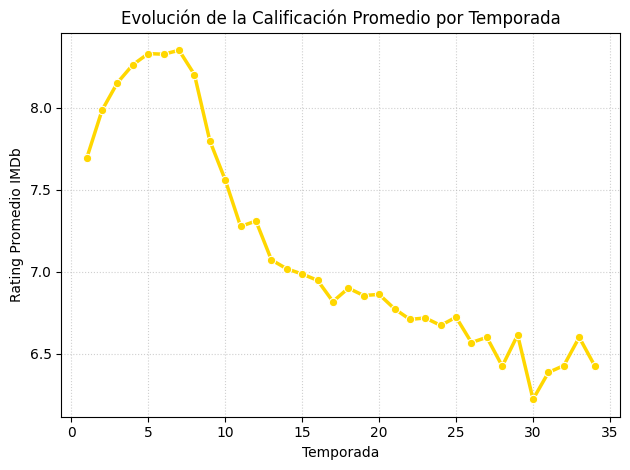

In [12]:
# Agrupar por temporada y sacar el promedio del rating
rating_por_temporada = data.groupby('season')['imdb_rating'].mean().reset_index()

# Graficar la línea de evolución
sns.lineplot(data=rating_por_temporada, x='season', y='imdb_rating', marker='o', color='gold', linewidth=2.5)

plt.title('Evolución de la Calificación Promedio por Temporada')
plt.xlabel('Temporada')
plt.ylabel('Rating Promedio IMDb')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('evolucion_temporadas.png')

El rating promedio de IMDb sube desde la temporada 1 hasta alcanzar su punto más alto entre las temporadas 5 y 7 aprox.
A partir de la temporada 8 comienza una caída continua que manda las notas por debajo de los 7.0 puntos desde la temporada 15 en adelante. Las últimas temporadas se mantienen en la zona más baja de la serie, registrando su peor promedio histórico en la temporada 30.

### Los directores mejor evaluados

C:\Users\carla\AppData\Local\Temp\ipykernel_21896\1046330538.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_directores, x='imdb_rating', y='directed_by', palette='viridis')


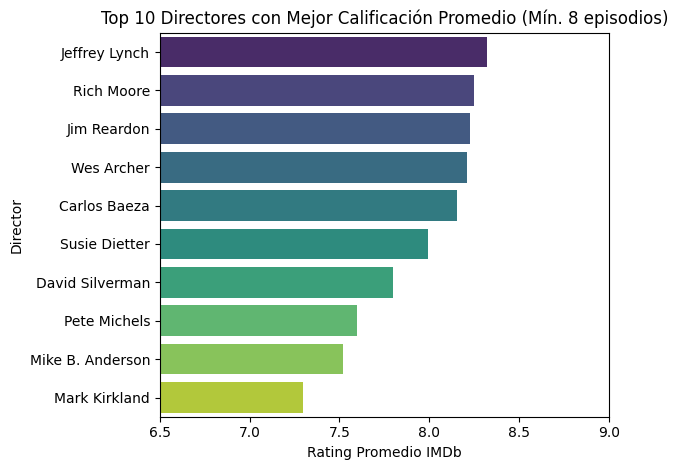

In [13]:
# filtrar directores con más de 8 episodios para que sea justo pq no todos han hecho igual cantidad
directores_frecuentes = data['directed_by'].value_counts()[data['directed_by'].value_counts() >= 8].index
df_directores = data[data['directed_by'].isin(directores_frecuentes)]

# sacar el promedio por director y ordenar de mejor a peor
top_directores = df_directores.groupby('directed_by')['imdb_rating'].mean().sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=top_directores, x='imdb_rating', y='directed_by', palette='viridis')

plt.title('Top 10 Directores con Mejor Calificación Promedio (Mín. 8 episodios)')
plt.xlabel('Rating Promedio IMDb')
plt.ylabel('Director')

plt.xlim(6.5, 9.0) 
plt.tight_layout()
plt.savefig('top_directores.png')

Al contrastar los datos, Jeffrey Lynch lidera las mejores calificaciones de la serie, pero ni siquiera figura en la lista de los que más han trabajado. Esto demuestra claramente que dirigir más capítulos no asegura tener mejores notas en IMDb. Un ejemplo evidente es Mark Kirkland, quien a pesar de ser el director con más episodios acumulados en la historia del show, cierra el Top 10 con el promedio más bajo del grupo.

### Los escritores mejor evaluados

C:\Users\carla\AppData\Local\Temp\ipykernel_21896\3106183439.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_escritores, x='imdb_rating', y='written_by', palette='viridis')


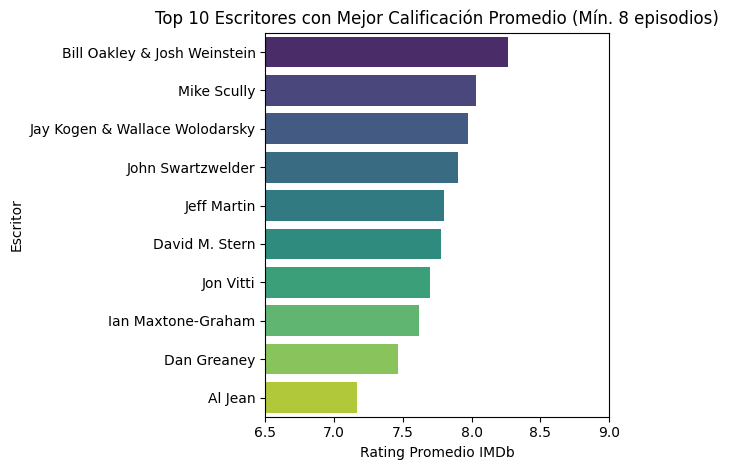

In [14]:
# filtrar escritores con más de 8 episodios para que sea justo
escritores_frecuentes = data['written_by'].value_counts()[data['written_by'].value_counts() >= 8].index
df_escritores = data[data['written_by'].isin(escritores_frecuentes)]

# sacar el promedio por escritor y ordenar de mejor a peor
top_escritores = df_escritores.groupby('written_by')['imdb_rating'].mean().sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=top_escritores, x='imdb_rating', y='written_by', palette='viridis')

plt.title('Top 10 Escritores con Mejor Calificación Promedio (Mín. 8 episodios)')
plt.xlabel('Rating Promedio IMDb')
plt.ylabel('Escritor')

plt.xlim(6.5, 9.0) 
plt.tight_layout()
plt.savefig('top_escritores.png')

Al contrastar los datos de los escritores, se repite la misma tendencia que para los directores; escribir más guiones tampoco asegura mejores notas en IMDb. El dúo de Bill Oakley & Josh Weinstein lidera el ranking con el mejor promedio de la serie, a pesar de no figurar entre los que más episodios han redactado. Por el contrario, John Swartzwelder, quien es por lejos el que más capítulos ha escrito en la historia del show (55 en total), se posiciona recién en el cuarto lugar

### Audiencia vs mejores episodios

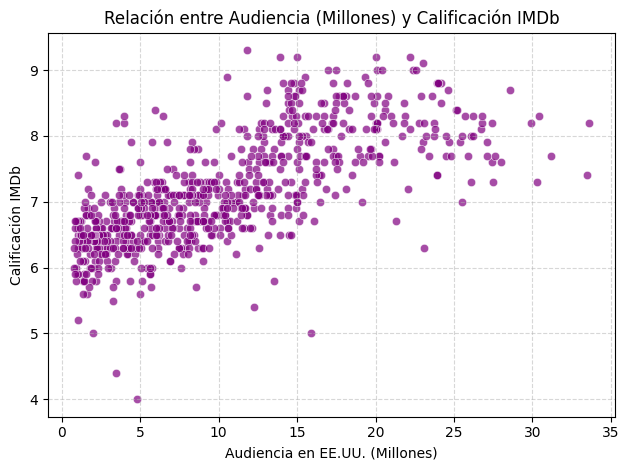

In [15]:
# Gráfico de dispersión con puntitos
sns.scatterplot(data=data, x='us_viewers_in_millions', y='imdb_rating', alpha=0.7, color='purple')

plt.title('Relación entre Audiencia (Millones) y Calificación IMDb')
plt.xlabel('Audiencia en EE.UU. (Millones)')
plt.ylabel('Calificación IMDb')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('audiencia_vs_rating.png')

A mayor cantidad de audiencia en millones en USA, las calificaciones en IMDb tienden a ser notablemente más altas.
La mayor concentración de episodios se agrupa por debajo de los 15 millones de espectadores, donde los puntajes varían entre los 5.0 y 8.5 puntos. Por el contrario, los capítulos que superan los 20 millones de espectadores tienen excelentes evaluaciones por encima de la nota 7.5

### Correlación

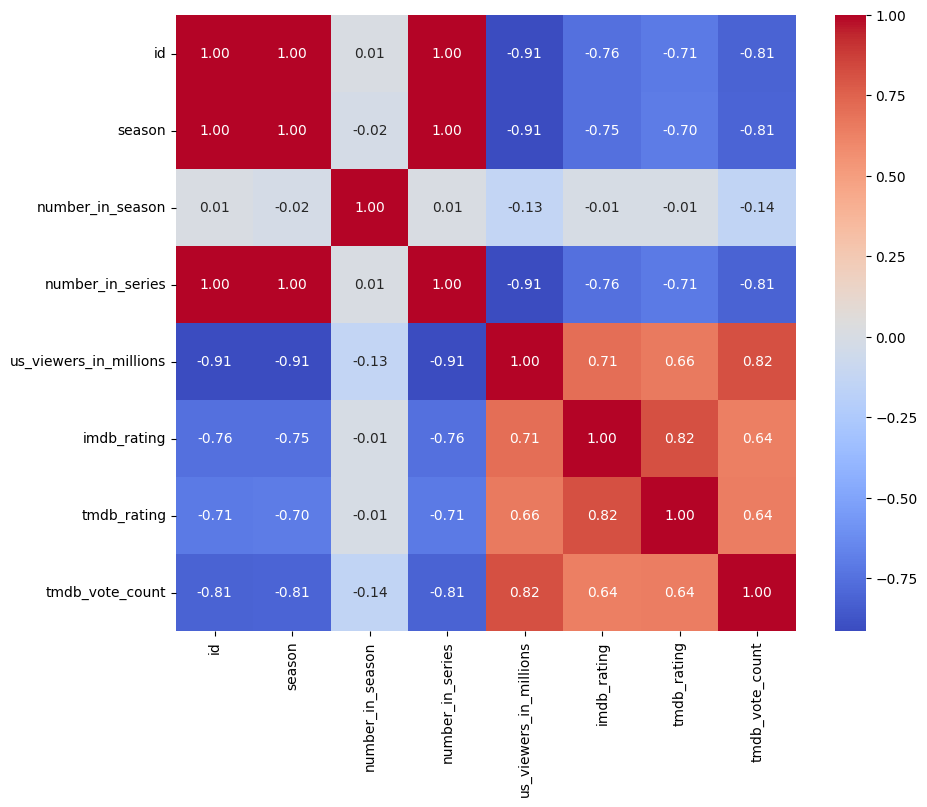

In [16]:
corr = data.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.show()

hay una correlación positiva entre la audiencia, las calificaciones y la cantidad de votos, asi se explica que los capítulos más vistos son también los mejor evaluados. Por el contrario, las variables de temporadas y números de episodios presentan un impacto negativo, reflejando que a medida que la serie avanza, tanto el público como las notas caen drásticamente

## Feature engineering

In [17]:
# Como el id solo es un número secuencial que no aporta información relevante para el análisis, lo eliminamos
#También como el objetivo es correlacionar y predecir a travpés del imdb_rating se elimina el tmdb_rating para evitar que el modelo se base en esa variable que es muy similar al imdb_rating y no aporta valor predictivo
# las variables categóricas como directed_by y written_by se transformarán mediante one hot encoding para que puedan ser utilizadas por el modelo.
# el title, original_air_date y production_code tampoco aportan valor predictivo
data = data.drop(columns=['id', 'tmdb_rating', 'title', 'original_air_date', 'production_code', 'description'])

#también en el EDA se vio que había una columna sin un dato, el us_viewers_in_millions, que como tiene datos NaN se elimina
data = data.dropna()

#se define x e y para el modelo, donde x son las variables predictoras y y es la variable objetivo que queremos predecir, en este caso el imdb_rating
X = data.drop(columns=['imdb_rating'])
y = data['imdb_rating']

## Feature selection

In [18]:
# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# separo las columnas numéricas de las categóricas para aplicarles diferentes transformaciones, como estandarización para las numéricas y one hot encoding para las categóricas
columnas_numericas = ['season', 'number_in_season', 'number_in_series', 'us_viewers_in_millions']
columnas_categoricas = ['directed_by', 'written_by']

#el preprocessor aplica las transformaciones necesarias a las columnas numéricas y categóricas, como estandarización para las numéricas y one hot encoding para las categóricas, para que el modelo pueda trabajar con ellas bien
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), columnas_categoricas)
    ]
)

## Entrenamiento

In [19]:
# se crea el Pipeline que asocia el preprocesamiento y la LR
model_pipeline = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('regresion_lineal', LinearRegression())
])

# La cross validation usará 5 folds pasándole el pipeline completo para evitar data leakage
scores = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='r2')

# Entrenamos el pipeline final en el conjunto de entrenamiento
model_pipeline.fit(X_train, y_train)

c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\carla\minic

,steps,"[('preprocesamiento', ...), ('regresion_lineal', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Control de overfitting

In [20]:
# se calcula el r2 en el conjunto de entrenamiento a través del pipeline
r2_train = model_pipeline.score(X_train, y_train)

#se calcula el r2 en la cross validation 
r2_cv = scores.mean()

print(f"R² en Train con LR: {r2_train:.3f}")
print(f"R² en Validación Cruzada (5-Fold) con LR: {r2_cv:.3f}")

R² en Train con LR: 0.775
R² en Validación Cruzada (5-Fold) con LR: 0.441


Al principio, la regresión lineal obtuvo un 0.775 con los datos de entrenamiento porque se los aprendió de memoria. Pero al probarlo con datos nuevos mediante validación cruzada para controlar este problema, su rendimiento real cayó a 0.441, demostrando que estaba sobreajustado

### Regularizadores para reducir overfitting detectado durante la cross validation

Para solucionar esto, se probará con los regularizadores Ridge, Lasso y Elastic Net con el fin de castigar al modelo por su complejidad y obligarlo a generalizar mejor con datos nuevos.

### Ridge

In [21]:
#pipeline con Ridge, con alpha=1.0 que es el valor por defecto

ridge_pipeline = Pipeline([
    ('preprocesamiento', preprocessor),
    ('ridge', Ridge(alpha=1.0))
])

#se calcula el r2 en la cross validation para el pipeline con Ridge, para comparar con el de la regresión lineal y ver si mejora el resultado al aplicar regularización
ridge_scores = cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring='r2')
#despues de calcular el r2 en la cross validation, se entrena el pipeline con Ridge en el conjunto de entrenamiento para luego evaluar su rendimiento en el conjunto de prueba y comparar con la regresión lineal sin regularización
ridge_pipeline.fit(X_train, y_train)

print("R² Ridge: ", ridge_scores.mean())

R² Ridge:  0.5581036017941756


c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\carla\minic

Con la regularización Ridge, el rendimiento real del modelo subió a 0.558 de precisión. Al aplicarle este castigo a los coeficientes, se logra controlar el overfitting anterior y mejorar su capacidad predictoria

### Lasso

In [22]:
#pipeline con Lasso, con alpha=0.01 para aplicar una regularización más fuerte que la de Ridge y ver si mejora el resultado al aplicar una regularización más fuerte
lasso_pipeline = Pipeline([
    ('preprocesamiento', preprocessor),
    ('lasso', Lasso(alpha=0.01))
])
#saco el cross validation para el pipeline con Lasso, para comparar con el de la regresión lineal y el de Ridge y ver si mejora el resultado al aplicar una regularización aun más fuerte
lasso_scores = cross_val_score(lasso_pipeline, X_train, y_train, cv=5, scoring='r2')

print("R² Lasso: ", lasso_scores.mean())

c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


R² Lasso:  0.5645095452389903


c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Al probar con Lasso, el r2 mejoró un poco más llegando a 0.564. Este regularizador ayudó a eliminar por completo las variables menos importantes para quedarse solo con lo que de verdad aporta al resultado

### Elastic Net

In [23]:
#pipeline con Elastic Net, que combina la regularización de Ridge y Lasso, con alpha=0.1 y l1_ratio=0.5 para aplicar una regularización intermedia entre Ridge y Lasso y ver si mejora el resultado al aplicar una regularización combinada
elastic_base_pipeline = Pipeline([
    ("preprocesamiento", preprocessor),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])
#le agrego una búsqueda de hiperparámetros con GridSearchCV para encontrar los mejores valores de alpha y l1_ratio para el modelo
params = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}
#aqui el grid search hace una búsqueda exhaustiva de los mejores hiperparámetros para el modelo de Elastic Net
grid_search = GridSearchCV(
    elastic_base_pipeline,
    params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
#despues de configurar el grid search, se entrena con el conjunto de entrenamiento para encontrar los mejores hiperparámetros y el mejor modelo de Elastic Net
grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor R² Elastic Net (CV):", grid_search.best_score_)
#saco el mejor modelo de Elastic Net encontrado por el grid search para luego evaluarlo en el conjunto de prueba y comparar con los otros modelos
elastic_pipeline = grid_search.best_estimator_

Mejores parámetros: {'model__alpha': 0.01, 'model__l1_ratio': 0.1}
Mejor R² Elastic Net (CV): 0.5892325595206802


Elastic Net superó a los dos anteriores logrando el mejor rendimiento con un r2 de 0.589 mediante validación cruzada.Para llegar a este resultado, el algoritmo combinó los castigos de Ridge y Lasso usando sus parámetros óptimos

In [24]:
print(f"Regresión Lineal: {scores.mean():.3f}")
print(f"Ridge: {ridge_scores.mean():.3f}")
print(f"Lasso: {lasso_scores.mean():.3f}")
print(f"Elastic Net: {grid_search.best_score_:.3f}")

Regresión Lineal: 0.441
Ridge: 0.558
Lasso: 0.565
Elastic Net: 0.589


A pesar de que Elastic Net es el modelo que mejor aporta,se procederá a primero iniciar con una Regresión Lineal para establecer una base de comparación

## Testeo: Regresión lineal

In [25]:
# Se evalúa el modelo de LR en el conjunto de test pasándolo por el pipeline para ver cómo generaliza
y_pred = model_pipeline.predict(X_test)

c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Visualización de resultados Y Métricas: Regresión lineal

R²: 0.562
MAE: 0.424
RMSE: 0.532


c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


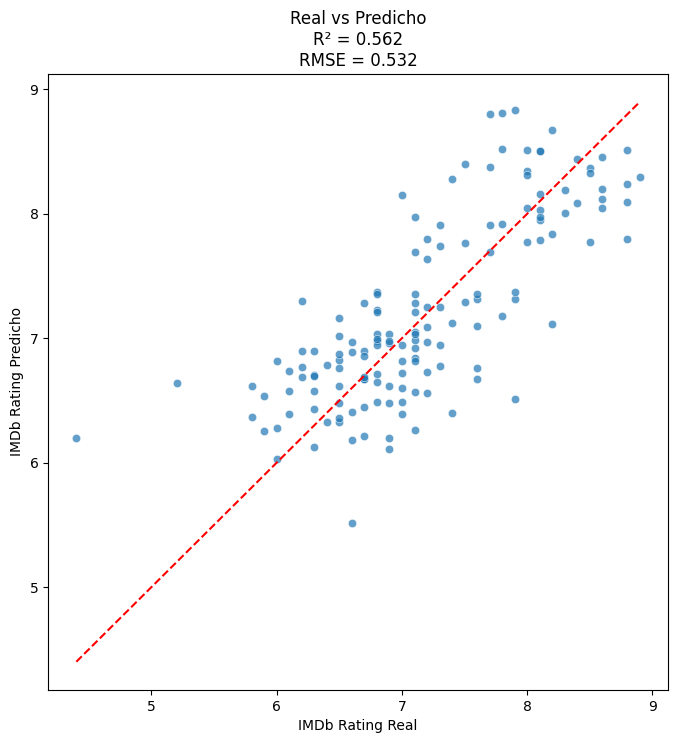

In [26]:
# Calcular métricas finales con regresion lineal sin regularización para comparar con los modelos con regularización
mae = mean_absolute_error(y_test, y_pred)#mae es la media de las diferencias absolutas entre las predicciones y los valores reales, mide el error promedio sin importar la dirección del error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))#rmse mide la diferencia promedio entre los valores predichos por el modelo y los valores reales
r2 = r2_score(y_test, y_pred) #aca saco el r2 nuevamente


print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

# grafico de predicciones

y_pred = model_pipeline.predict(X_test)

plt.figure(figsize=(8,8))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)

plt.xlabel("IMDb Rating Real")
plt.ylabel("IMDb Rating Predicho")
plt.title(f"Real vs Predicho\nR² = {r2:.3f}\nRMSE = {rmse:.3f}")

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--', color='red')

plt.show()


Al evaluar el modelo de regresión lineal sin castigos en el conjunto de testeo, se obtuvo un r2 de 0.562, un error absoluto promedio (MAE) de 0.424 y un RMSE de 0.532. El gráfico refleja este comportamiento mostrando que los puntos se agrupan relativamente cerca de la línea roja ideal, lo que confirma que el modelo predice con una precisión aceptable el rating real en esta etapa

### Variables con mayor influencia sobre el IMDb en el modelo de LR 

In [27]:
#aca saco los nombres de todas las columnas transformadas por el preprocesamiento
feature_names = model_pipeline.named_steps["preprocesamiento"].get_feature_names_out()
# se crea un df que asocia cada variable con su coeficiente del modelo
coeficientes = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": model_pipeline.named_steps["regresion_lineal"].coef_
})
#ordena los coeficientes de menor a mayor para identificar el impacto de cada variable
coeficientes = coeficientes.sort_values("Coeficiente")
coeficientes

,Variable,Coeficiente
2,num__number_in_series,-8.144561
154,cat__written_by_Neil Campbell,-1.380291
25,cat__directed_by_Mark Ervin,-1.207966
119,cat__written_by_Jeff Martin & Samantha Martin,-1.166517
136,cat__written_by_Ken Levine & David Isaacs,-1.122720
...,...,...
175,cat__written_by_Steve Young,0.827442
16,cat__directed_by_Jeff Lynch,0.965115
69,cat__written_by_Carolyn Omine & Ryan Koh & Mat...,1.551657
166,cat__written_by_Rob LaZebnik & Johnny LaZebnik,1.557809


En la regresión lineal sin la regularización, los coeficientes toman estos valore debido a la falta de penalización por complejidad. La variable de temporada num__season presenta un impacto positivo alto de 7.728, el cual se contrarresta directamente con el coeficiente negativo de -8.144 asignado al número de episodio de la serie num__number_in_series. Respecto a los nombres, el guion de Rob & Johnny LaZebnik es el que mayor peso positivo aporta con 1.557, mientras que el de Neil Campbell registra la mayor influencia negativa con -1.380

C:\Users\carla\AppData\Local\Temp\ipykernel_21896\4170068122.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(most_important.Variable, rotation=90)


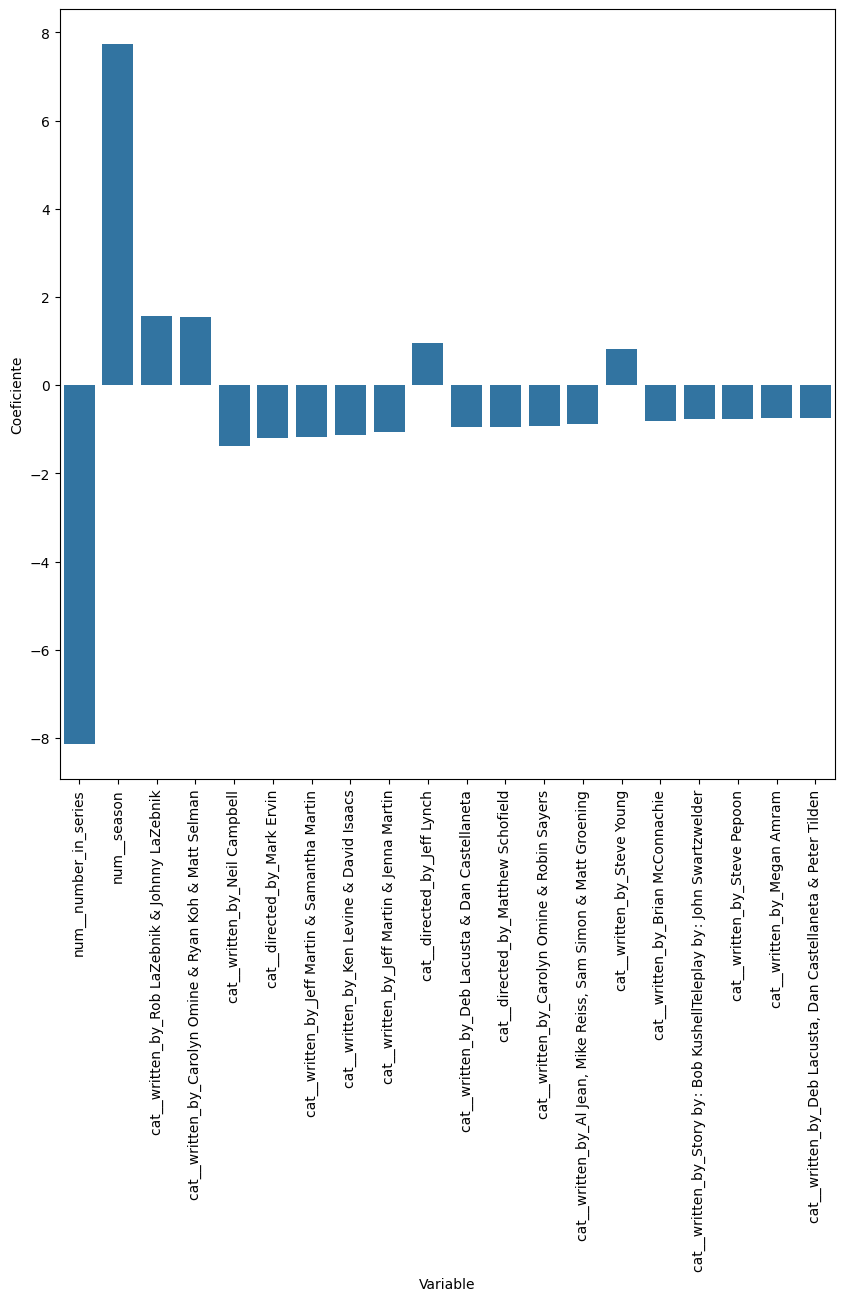

In [28]:
coeficientes["abs_coef"] = coeficientes["Coeficiente"].abs()
most_important = coeficientes.sort_values(by="abs_coef", ascending=False)[:20]
fig, ax = plt.subplots(figsize=(10,10))
ax = sns.barplot(most_important, x = "Variable", y = "Coeficiente", axes=ax)
ax.set_xticklabels(most_important.Variable, rotation=90)
plt.show()

## Evaluación comparativa con Elastic Net

Dado que Elastic Net obtuvo el mejor desempeño durante la etapa de validación cruzada (R² = 0.58), se utilizará este modelo para el testeo, no se volverá a entrar porque el entrenamiento ya fue hecho previamente. El objetivo es comparar su rendimiento en el conjunto de prueba con el obtenido previamente por la regresión lineal sin regularización y evaluar si la incorporación de un regularizador mejora la capacidad de generalización del modelo.

### Testeo: Elastic Net

In [29]:
y_pred_elastic = elastic_pipeline.predict(X_test)

c:\Users\carla\miniconda3\envs\Ejercicios\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### Visualización de resultados y Métricas: Elastic Net

In [30]:
#se obtienen las métricas pero con Elastic net como regulador del overfit

mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
r2_elastic = r2_score(y_test, y_pred_elastic)

print(f"Elastic Net R²: {r2_elastic:.3f}")
print(f"Elastic Net MAE: {mae_elastic:.3f}")
print(f"Elastic Net RMSE: {rmse_elastic:.3f}")

Elastic Net R²: 0.600
Elastic Net MAE: 0.390
Elastic Net RMSE: 0.508


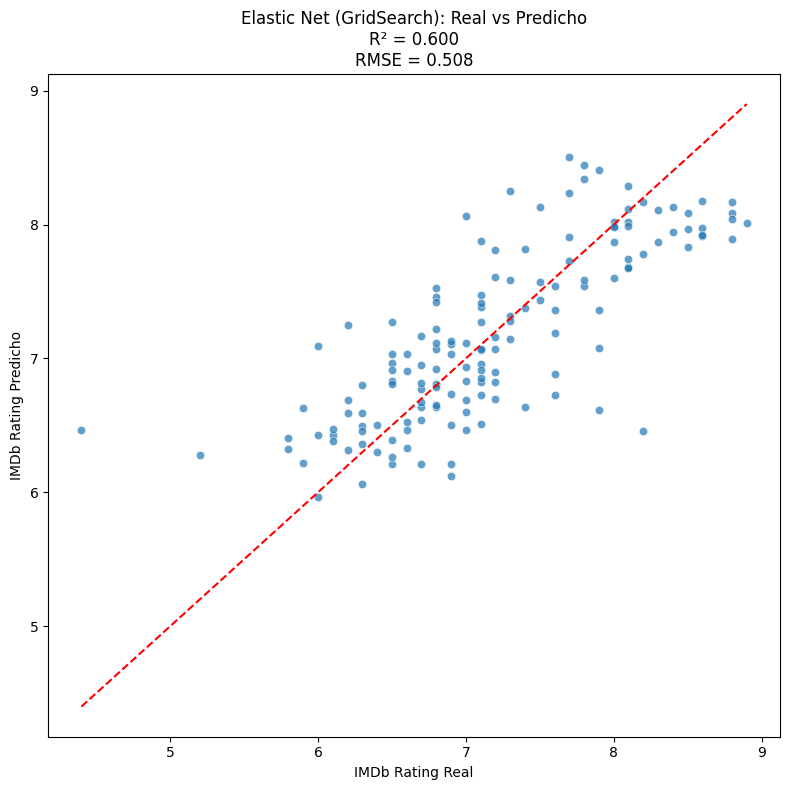

In [31]:
# Gráfico para Elastic Net
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_elastic, alpha=0.7)

plt.xlabel("IMDb Rating Real")
plt.ylabel("IMDb Rating Predicho")
plt.title(f"Elastic Net (GridSearch): Real vs Predicho\nR² = {r2_elastic:.3f}\nRMSE = {rmse_elastic:.3f}")

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--',
         color='red')

plt.tight_layout()
plt.show()

Al aplicar la regularización definitiva con Elastic Net, el rendimiento en el conjunto de testeo mejoró notablemente, alcanzando un r2 de 0.600. Esto significa que el modelo ahora es capaz de explicar el 60% de la variabilidad del rating de los episodios utilizando los datos penalizados. Asimismo, las métricas de error disminuyeron en comparación con la regresión lineal: el MAE bajó a 0.390 puntos y el RMSE se redujo a 0.508. También el gráfico de dispersión muestra una leve mejora en comparación al scatterplot de LR, mostrando una concentración mucho más alineada y compacta de los puntos alrededor de la diagonal, lo que valida la efectividad de la penalización

## Justificación de elección del modelo vs otros

- Regresión logística: No se utilizó porque este algoritmo está diseñado para problemas de clasificación. Siguiendo la teoría clásica de selección de modelos, la Regresión Logística se descartó debido a la naturaleza de la variable objetivo (imdb_rating). Mientras que la regresión logística es un algoritmo de clasificación diseñado para predecir probabilidades y resultados categóricos binarios (como decidir si un correo es spam o no), este proyecto quería estimar un valor numérico continuo. 

- PCA : no se seleccionó debido a que el conjunto de datos cuenta con un número reducido de variables predictoras (14 columnas), por lo que no existía un problema de alta dimensionalidad. Además, el uso de PCA transforma las variables originales en componentes principales y abstractos, reduciendo la interpretabilidad del modelo e impedido medir el impacto directo de cada director y guionista en el rating de la serie.

- Naive Bayes: Naive Bayes es un algoritmo de clasificación diseñado para predecir categorías o etiquetas discretas. Dado que el objetivo de este proyecto es predecir el imdb_rating que es un puntaje numérico continuo, este algoritmo resulta inaplicable. Además, aunque el dataset contiene variables de texto (como los nombres de directores y guionistas), estas funcionan como variables categóricas que influyen en una escala numérica, por lo que el problema no requiere visión de clasificación.

- K-Nearest Neighbors (KNN): Aunque epuede para predecir valores continuos, se descartó su aplicación siguiendo los criterios de la literatura. Al aplicar One-Hot Encoding sobre las variables de directores y guionistas (que son categóricas con múltiples niveles), el dataset se expandió a un espacio de alta dimensionalidad. Como explica la literatura, en espacios con demasiadas dimensiones el cálculo de distancia geométrica pierde sentido debido a que todos los puntos comienzan a parecerse entre sí y aparece la "curse of dimensionality". Por lo tanto, KNN se vuelve incapaz de encontrar vecinos verdaderamente representativos.

- Decision Trees: aunque es capaz de estimar variables continuas y manejar datos categóricos de manera nativa, se descartó su uso debido a sus marcadas desventajas estructurales. Como se señala en la literatura, los árboles de decisión son altamente propensos al overfitting, tendiendo a memorizar el ruido de los datos de entrenamiento cuando se trabaja con datasets pequeños como este de 747 filas. Al haber expandido las categorías de directores y guionistas mediante One-Hot Encoding, el algoritmo genera árboles excesivamente complejos, profundos y altamente sensibles a pequeñas variaciones en los datos. 

- Random Forest: este algoritmo es muy bueno contra el overfitting, se descartó debido a su naturaleza de "black box". Como se destaca al compararlo con los decision trees, un Random Forest es considerablemente más complejo de interpretar y visualizar. Al hacer bagging promediando las predicciones de múltiples árboles entrenados con subconjuntos aleatorios de datos y características, se pierde la trazabilidad de los coeficientes.

## Referencias

- Fandom. (s.f.). Categoría:Directores. Los Simpson Wiki. https://simpsons.fandom.com/es/wiki/Categor%C3%ADa:Directores

- Fandom. (s.f.). Categoría:Guionistas de Los Simpson. Los Simpson Wiki. https://simpsons.fandom.com/es/wiki/Categor%C3%ADa:Guionistas_de_Los_Simpson

- IBM. (2025). ¿Qué es la multicolinealidad? IBM Think Topics. https://www.ibm.com/es-es/think/topics/multicollinearity

- IBM. (2025). What is data leakage in machine learning? IBM Think Topics. https://www.ibm.com/think/topics/data-leakage-machine-learning

- Sharma, A. (2022, 12 de julio). Step-by-step exploratory data analysis (EDA) using Python. Analytics Vidhya. https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/

- Singh, A. (2023, 22 de diciembre). Building smarter ML pipelines with column transformers. Medium. https://medium.com/@abhaysingh71711/building-smarter-ml-pipelines-with-column-transformers-895904e97254

- Zhihu. (2023, 11 de mayo). Respuesta a una consulta de ML (Respuesta N.º 3002775487). Zhihu. https://www.zhihu.com/en/answer/3002775487

- Lindeman, M., PhD. (s. f.). Logistic Regression vs Linear Regression: When to Use Which. https://www.quadratichq.com/blog/logistic-regression-vs-linear-regression-when-to-use-which-approach

- Loukas, S., PhD. (2025, 21 enero). PCA clearly explained – How, when, why to use it and feature importance: A guide in Python. Towards Data Science. https://towardsdatascience.com/pca-clearly-explained-how-when-why-to-use-it-and-feature-importance-a-guide-in-python-7c274582c37e/ 

- GeeksforGeeks. (2026, 27 febrero). Naive Bayes classifiers. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/naive-bayes-classifiers/

- Kartik, N. (2026, 14 mayo). K-Nearest Neighbor (KNN) in 2026: How It Works and When to Use It. Future AGI. https://futureagi.com/blog/k-nearest-neighbor/

- Dun, O. (2025, 26 febrero). Árboles de Decisión en Machine Learning: Predicciones efectivas y modelos interpretables. Codemotion Magazine. https://www.codemotion.com/magazine/es/inteligencia-artificial/arboles-de-decision-en-machine-learning-predicciones-efectivas-y-modelos-interpretables/

- How Is Random Forest Used For Classification and Regression Problems? (s. f.). https://h2o.ai/wiki/random-forest/